# E-commerce Sales Analysis Project

### Author: Yaroslav Pryimak

**Objective:**
Analyze large sales dataset to identify trends, best-selling products, and optimize advertising strategies.

**Key Business Questions:**
1. What was the best month for sales?
2. Which city sold the most products?
3. What time should we display advertisements to maximize likelihood of customer's buying products?
4. What products are most often sold together?

In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

# Display settings for cleaner float output
pd.set_option('display.float_format', lambda x: '%.2f' % x)
# Chart style
plt.style.use('ggplot')

## Step 1: Data Loading and Merging
Collecting data from 12 separate CSV files into a single DataFrame.

In [2]:
# Define path (Update this path to your local folder)
path = r'D:\DataAnalystPortfolioProjects\Project 5 - Python\Dataset'

# Get all .csv files
all_files = glob.glob(os.path.join(path, '*.csv'))

# Merge files
all_data = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

# Create a working copy
df = all_data.copy()

# Preview
print(f"Total rows: {df.shape[0]}")
df.head()

Total rows: 186850


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


## Step 2: Data Cleaning
Removing null values, duplicates, and fixing data types.

In [3]:
# 1. Drop rows where ALL values are NaN
df = df.dropna(how='all')

# 2. Filter out repeated headers (junk data)
df = df[df['Order Date'] != 'Order Date']

# 3. Fix Data Types
# Using .loc to modify the dataframe safely
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'])
df['Price Each'] = pd.to_numeric(df['Price Each'])
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%y %H:%M')

# Reset index after dropping rows
df = df.reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185950 non-null  object        
 1   Product           185950 non-null  object        
 2   Quantity Ordered  185950 non-null  int64         
 3   Price Each        185950 non-null  float64       
 4   Order Date        185950 non-null  datetime64[ns]
 5   Purchase Address  185950 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 8.5+ MB


## Step 3: Feature Engineering
Extracting Month, City, State, and Revenue columns for analysis.

In [4]:
# 1. Add Sales Column (Revenue)
df['Sales'] = df['Quantity Ordered'] * df['Price Each']

# 2. Add Month Column (for sorting)
df['Month'] = df['Order Date'].dt.month

# 3. Add City Column
# Logic: We must include State (e.g., "Portland (OR)" vs "Portland (ME)") to avoid duplicates.
def get_city(address):
    return address.split(',')[1]

def get_state(address):
    return address.split(',')[2].split(' ')[1]

# Apply the function
df['City'] = df['Purchase Address'].apply(lambda x: f"{get_city(x)} ({get_state(x)})")

# 4. Add Hour Column
df['Hour'] = df['Order Date'].dt.hour

# Check result
df[['Order ID', 'City', 'Sales', 'Month', 'Hour']].head()

,Order ID,City,Sales,Month,Hour
0,176558,Dallas (TX),23.90,4,8
1,176559,Boston (MA),99.99,4,22
2,176560,Los Angeles (CA),600.00,4,14
3,176560,Los Angeles (CA),11.99,4,14
4,176561,Los Angeles (CA),11.99,4,9


## Step 4: Analysis & Visualization

### Q1: What was the best month for sales?

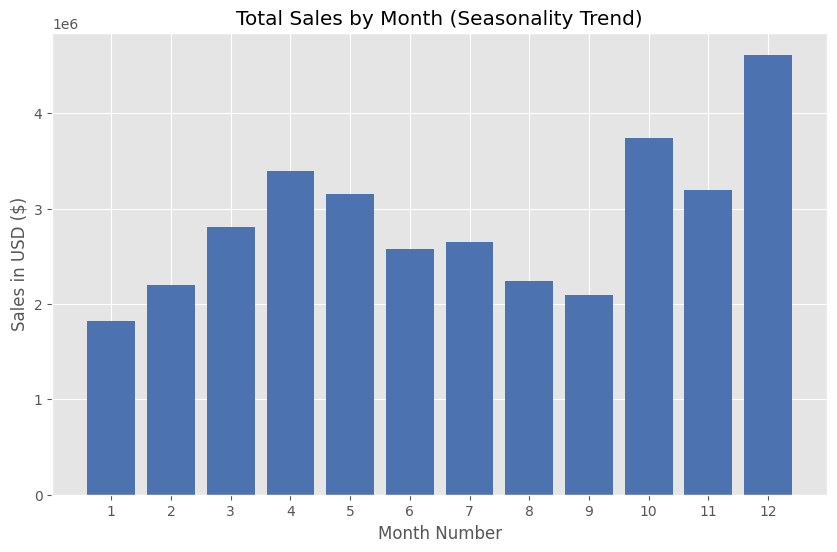

In [5]:
# Group by Month Number to keep chronological order (Jan=1, Feb=2...)
results_month = df.groupby('Month').sum(numeric_only=True)

# Plotting
months = range(1, 13)

plt.figure(figsize=(10, 6))
plt.bar(months, results_month['Sales'], color='#4c72b0') # Professional Blue

plt.xticks(months)
plt.ylabel('Sales in USD ($)')
plt.xlabel('Month Number')
plt.title('Total Sales by Month (Seasonality Trend)')
plt.show()

### Q2: Which city sold the most products?

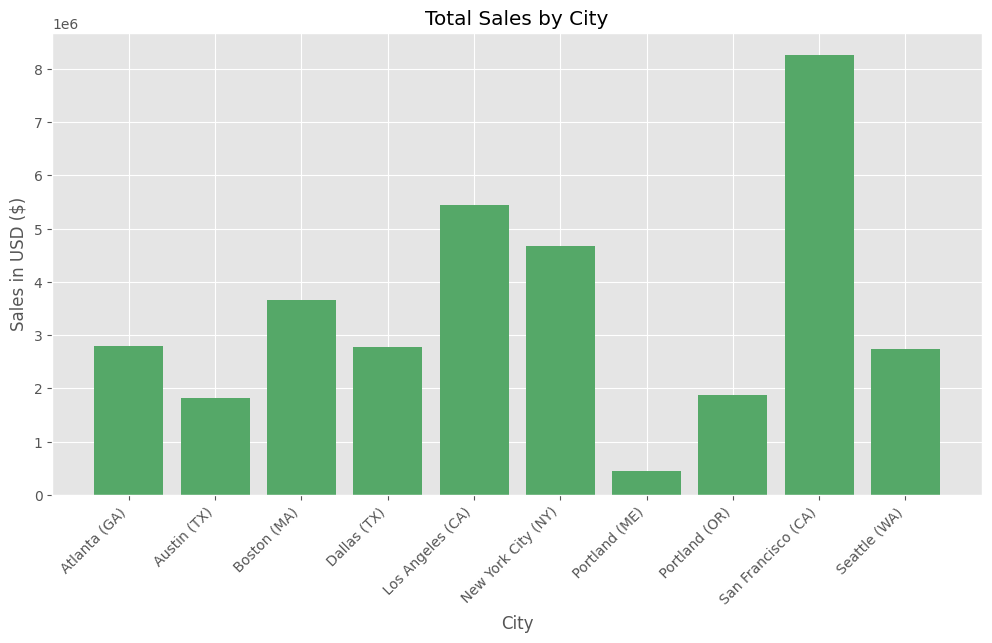

In [6]:
# Group by City
results_city = df.groupby('City').sum(numeric_only=True)

# Prepare data for plotting
# Note: simple .index gets cities in alphabetical order, which matches the groupby sum
cities = results_city.index

plt.figure(figsize=(12, 6))
plt.bar(cities, results_city['Sales'], color='#55a868') # Professional Green

plt.xticks(rotation=45, ha='right', size=10) # Rotate labels
plt.ylabel('Sales in USD ($)')
plt.xlabel('City')
plt.title('Total Sales by City')
plt.show()

### Q3: What time should we display advertisements?

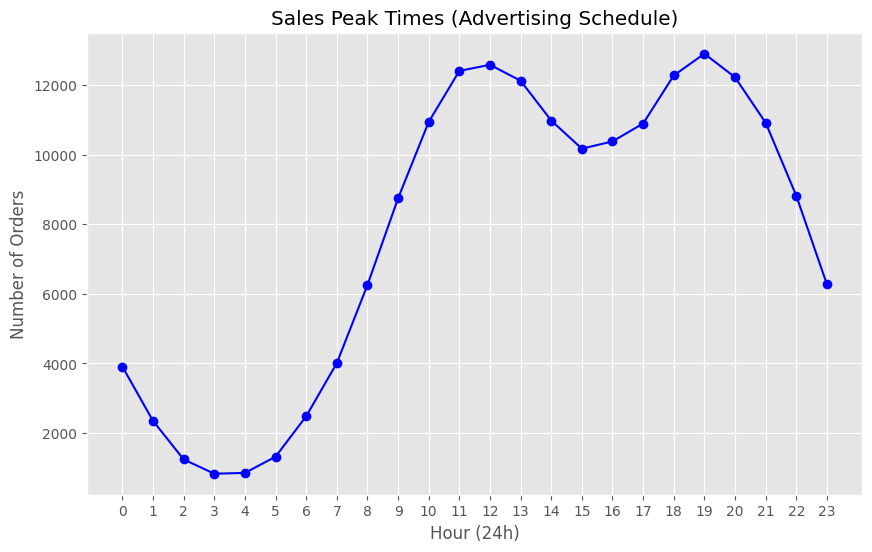

Insight: Advertising should focus on 11:00-12:00 and 19:00 (7 PM).


In [7]:
# Group by Hour and count orders
hourly_counts = df.groupby(['Hour']).count()
hours = hourly_counts.index

plt.figure(figsize=(10, 6))
plt.plot(hours, hourly_counts['Quantity Ordered'], color='b', marker='o')

plt.xticks(hours)
plt.xlabel('Hour (24h)')
plt.ylabel('Number of Orders')
plt.title('Sales Peak Times (Advertising Schedule)')
plt.grid(True)
plt.show()

print("Insight: Advertising should focus on 11:00-12:00 and 19:00 (7 PM).")

### Q4: What products are most often sold together?

In [8]:
# 1. Filter orders with multiple items
df_dup = df[df['Order ID'].duplicated(keep=False)].copy()

# 2. Group items into a single string per Order ID
df_dup['Grouped'] = df_dup.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))

# 3. Drop duplicate orders
df_dup = df_dup[['Order ID', 'Grouped']].drop_duplicates()

# 4. Count pairs
count = Counter()

for row in df_dup['Grouped']:
    row_list = row.split(',')
    # Calculate combinations of 2 items
    count.update(Counter(combinations(row_list, 2)))

print("Top 10 Most Common Product Pairs:")
for key, value in count.most_common(10):
    print(f"{key}: {value} times")

Top 10 Most Common Product Pairs:
('iPhone', 'Lightning Charging Cable'): 1005 times
('Google Phone', 'USB-C Charging Cable'): 987 times
('iPhone', 'Wired Headphones'): 447 times
('Google Phone', 'Wired Headphones'): 414 times
('Vareebadd Phone', 'USB-C Charging Cable'): 361 times
('iPhone', 'Apple Airpods Headphones'): 360 times
('Google Phone', 'Bose SoundSport Headphones'): 220 times
('USB-C Charging Cable', 'Wired Headphones'): 160 times
('Vareebadd Phone', 'Wired Headphones'): 143 times
('Lightning Charging Cable', 'Wired Headphones'): 92 times


## Project Conclusion

1.  **Seasonality:** December is the strongest month for sales, indicating high demand during holidays.
2.  **Geography:** San Francisco (CA) is the leading city in sales volume.
3.  **Timing:** Customer activity peaks around 11 AM and 7 PM. These are optimal windows for targeted ads.
4.  **Bundling Strategy:** iPhones are frequently bought with Lightning Cables. This suggests a strong cross-selling opportunity.